# Equality Constrained Optimization

Solving constrained optimization using the Lagrangian method with GMM.

**Problem:** Gasoline blending to find the blend closest to a target recipe while meeting octane and mass balance constraints.

## System Information

This section documents the computational environment used to run this notebook.

In [1]:
import sys
import platform
import time
import psutil
import os

print("System Information")
print("=" * 70)
print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Processor: {platform.processor()}")
print(f"CPU count: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical")
print(f"Total memory: {psutil.virtual_memory().total / (1024**3):.2f} GB")
print("=" * 70)

# Key package versions
print("\nKey Library Versions:")
print("-" * 70)
packages = [
    ('numpy', 'np'),
    ('scipy', 'scipy'),
    ('matplotlib', 'matplotlib'),
    ('sklearn', 'sklearn'),
    ('torch', 'torch'),
    ('gmr', 'gmr'),
]

for pkg_name, import_name in packages:
    try:
        mod = __import__(pkg_name)
        version = getattr(mod, '__version__', 'unknown')
        print(f"{pkg_name:<20} {version}")
    except ImportError:
        print(f"{pkg_name:<20} NOT INSTALLED")

print("-" * 70)

# Initialize timing and memory tracking
_start_time = time.time()
_process = psutil.Process(os.getpid())
_start_memory_mb = _process.memory_info().rss / (1024 * 1024)

print(f"\nNotebook execution started: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"Initial memory usage: {_start_memory_mb:.2f} MB")
print("=" * 70)

System Information
Python version: 3.12.8 (main, Jan 14 2025, 23:36:58) [Clang 19.1.6 ]
Platform: macOS-15.7.2-arm64-arm-64bit
Processor: arm
CPU count: 14 physical, 14 logical
Total memory: 64.00 GB

Key Library Versions:
----------------------------------------------------------------------
numpy                2.3.4
scipy                1.16.2
matplotlib           3.10.1


sklearn              1.7.2


torch                2.4.1
gmr                  2.0.2
----------------------------------------------------------------------

Notebook execution started: 2025-12-18 10:59:56
Initial memory usage: 320.89 MB


## System Information

This section documents the computational environment used to run this notebook.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings

# Configure JAX to use CPU (avoids GPU/XLA compatibility issues)
import os
os.environ['JAX_PLATFORMS'] = 'cpu'

# Import reusable utilities from local module
from generative_optimization import (
    generate_samples,
    estimate_sample_size,
    best_gmm,
    best_gmm_bic,
    cluster_stats,
    validate_gmm
)

# Figure settings
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=RuntimeWarning)

---
<a id='constrained'></a>
## 4. Constrained Optimization

<a id='equality'></a>
### 4.1 Equality Constraints: Gasoline Blending

For equality constraints, we use a Lagrangian approach and condition on all Lagrangian derivatives being zero.

**Problem:** A refinery wants to find the blend composition closest to a target recipe while meeting an octane specification:

$$\min_{x_1, x_2, x_3} \quad (x_1 - 0.4)^2 + (x_2 - 0.4)^2 + (x_3 - 0.2)^2$$

Subject to:
- Octane constraint: $\text{RON}_1 x_1 + \text{RON}_2 x_2 + \text{RON}_3 x_3 = 87$
- Mass balance: $x_1 + x_2 + x_3 = 1$

| Component | Target | RON |
|-----------|--------|-----|
| Reformate ($x_1$) | 0.40 | 95 |
| Isomerate ($x_2$) | 0.40 | 82 |
| Alkylate ($x_3$)  | 0.20 | 94 |

In [3]:
# First, solve with scipy for comparison
from scipy.optimize import minimize

# Component parameters
x_target = np.array([0.4, 0.4, 0.2])  # Target blend
rons = np.array([95, 82, 94])  # Research Octane Number
ron_target = 87  # Regular gasoline specification

def objective(x):
    """Squared distance from target blend"""
    return np.sum((x - x_target)**2)

def octane_constraint(x):
    """RON constraint: sum(RON_i * x_i) = RON_target"""
    return np.dot(rons, x) - ron_target

def mass_balance(x):
    """Mass balance: sum(x_i) = 1"""
    return np.sum(x) - 1

constraints = [
    {'type': 'eq', 'fun': octane_constraint},
    {'type': 'eq', 'fun': mass_balance}
]

# Bounds: 0 <= x_i <= 1
bounds = [(0, 1), (0, 1), (0, 1)]

sol = minimize(objective, [0.33, 0.33, 0.34], 
               constraints=constraints, bounds=bounds, method='SLSQP')

print("Scipy solution (SLSQP):")
print(f"  Reformate (x1) = {sol.x[0]:.4f}")
print(f"  Isomerate (x2) = {sol.x[1]:.4f}")
print(f"  Alkylate  (x3) = {sol.x[2]:.4f}")
print(f"  Objective = {sol.fun:.6f}")
print(f"  RON achieved = {np.dot(rons, sol.x):.2f}")

Scipy solution (SLSQP):
  Reformate (x1) = 0.2841
  Isomerate (x2) = 0.6070
  Alkylate  (x3) = 0.1089
  Objective = 0.064586
  RON achieved = 87.00


In [4]:
# Define Lagrangian and use JAX for derivatives
from jax import jacobian, vmap
import jax.numpy as jnp

# Convert to JAX arrays for autodiff
x_target_jax = jnp.array([0.4, 0.4, 0.2])
rons_jax = jnp.array([95.0, 82.0, 94.0])
ron_target_jax = 87.0

def lagrangian(Y):
    """
    Lagrangian: L = objective + lambda1 * g1 + lambda2 * g2
    
    Y = [x1, x2, x3, lambda1, lambda2]
    g1 = octane constraint (RON - target)
    g2 = mass balance (sum - 1)
    """
    x = Y[0:3]
    lambda1, lambda2 = Y[3], Y[4]
    
    # Objective: squared distance from target blend
    obj = jnp.sum((x - x_target_jax)**2)
    
    # Constraints
    g1 = jnp.dot(rons_jax, x) - ron_target_jax  # Octane constraint
    g2 = jnp.sum(x) - 1.0  # Mass balance
    
    return obj + lambda1 * g1 + lambda2 * g2

print("Lagrangian defined with 2 equality constraints")
print("Variables: [x1, x2, x3, λ1, λ2]")
print("KKT conditions: ∂L/∂x1 = ∂L/∂x2 = ∂L/∂x3 = ∂L/∂λ1 = ∂L/∂λ2 = 0")

Lagrangian defined with 2 equality constraints
Variables: [x1, x2, x3, λ1, λ2]
KKT conditions: ∂L/∂x1 = ∂L/∂x2 = ∂L/∂x3 = ∂L/∂λ1 = ∂L/∂λ2 = 0


In [5]:
# Generate samples of [x1, x2, x3, lambda1, lambda2] and compute Lagrangian derivatives
# Bounds for blend fractions [0, 1] and Lagrange multipliers (estimate scale)
# For the minimum distance problem, λ2 ≈ -4.5 at the solution
bounds = [[0, 1], [0, 1], [0, 1], [-0.5, 0.5], [-6, 0]]
Y = generate_samples(bounds, n_samples=512, seed=42)

# Compute Jacobian of Lagrangian for each sample
dL = vmap(jacobian(lagrangian))(Y)

# Data: [x1, x2, x3, lambda1, lambda2, dL/dx1, dL/dx2, dL/dx3, dL/dlambda1, dL/dlambda2]
data = np.hstack([np.array(Y), np.array(dL)])
print(f"Data shape: {data.shape}")
print(f"Columns: [x1, x2, x3, λ1, λ2, ∂L/∂x1, ∂L/∂x2, ∂L/∂x3, ∂L/∂λ1, ∂L/∂λ2]")

Data shape: (512, 10)
Columns: [x1, x2, x3, λ1, λ2, ∂L/∂x1, ∂L/∂x2, ∂L/∂x3, ∂L/∂λ1, ∂L/∂λ2]


In [6]:
# Build GMM
gmm, info = best_gmm(data, verbose=True)
print(f"\nBest model: {info['best_k']} components")

k=1: BIC=-15515.5 *
k=2: BIC=-15181.4
k=3: BIC=-14824.5
k=4: BIC=-14445.4
k=5: BIC=-14085.2
k=6: BIC=-13673.6
k=7: BIC=-13328.4


k=8: BIC=-12971.5
k=9: BIC=-12576.2
k=10: BIC=-12217.7

Best model: 1 components


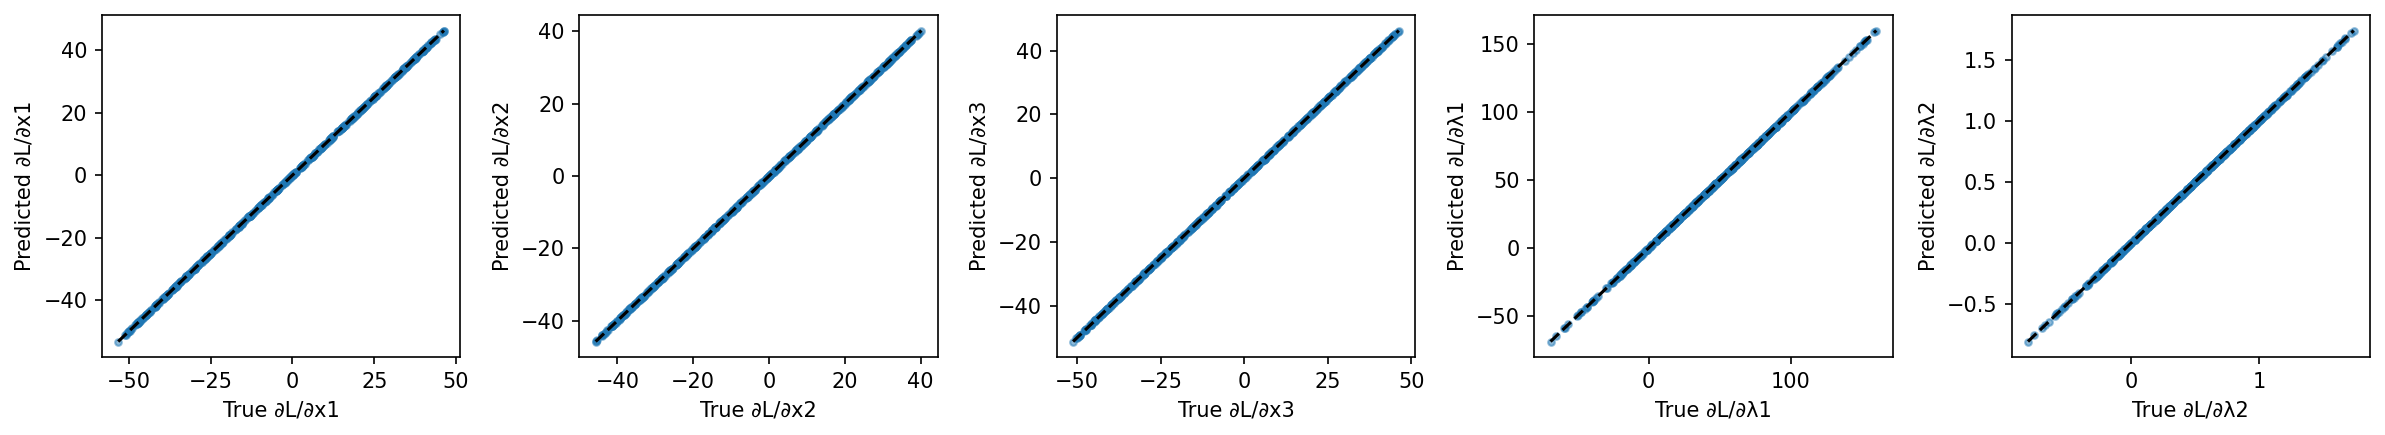

In [7]:
# Validate the model - predict derivatives given variables
pred = gmm.predict([0, 1, 2, 3, 4], data[:, 0:5])  # condition on x1,x2,x3,λ1,λ2

fig, axes = plt.subplots(1, 5, figsize=(16, 3))
labels = ['∂L/∂x1', '∂L/∂x2', '∂L/∂x3', '∂L/∂λ1', '∂L/∂λ2']

for i, (ax, label) in enumerate(zip(axes, labels)):
    true = data[:, 5+i]
    predicted = pred[:, i]
    ax.scatter(true, predicted, alpha=0.5, s=10)
    lims = [min(true.min(), predicted.min()), max(true.max(), predicted.max())]
    ax.plot(lims, lims, 'k--')
    ax.set_xlabel(f'True {label}')
    ax.set_ylabel(f'Predicted {label}')

plt.tight_layout()
plt.show()

In [8]:
# Solve: condition on all 5 Lagrangian derivatives = 0
P = gmm.predict([5, 6, 7, 8, 9], np.array([[0.0, 0.0, 0.0, 0.0, 0.0]]))

x1_opt, x2_opt, x3_opt = P[0, 0:3]
lambda1_opt, lambda2_opt = P[0, 3], P[0, 4]

print("Generative solution (conditioning on ∇L = 0):")
print(f"  Reformate (x1) = {x1_opt:.4f}")
print(f"  Isomerate (x2) = {x2_opt:.4f}")
print(f"  Alkylate  (x3) = {x3_opt:.4f}")
print(f"  λ1 (octane)    = {lambda1_opt:.6f}")
print(f"  λ2 (mass bal)  = {lambda2_opt:.6f}")

# Verify constraints and objective
print(f"\nVerification:")
print(f"  Sum of fractions: {x1_opt + x2_opt + x3_opt:.4f} (should be 1.0)")
print(f"  RON achieved: {95*x1_opt + 82*x2_opt + 94*x3_opt:.2f} (target: 87)")
obj_gmm = (x1_opt - 0.4)**2 + (x2_opt - 0.4)**2 + (x3_opt - 0.2)**2
print(f"  Objective (distance²): {obj_gmm:.6f}")

print(f"\nComparison with scipy: x = [{sol.x[0]:.4f}, {sol.x[1]:.4f}, {sol.x[2]:.4f}]")

Generative solution (conditioning on ∇L = 0):
  Reformate (x1) = 0.2845
  Isomerate (x2) = 0.6062
  Alkylate  (x3) = 0.1092
  λ1 (octane)    = 0.049491
  λ2 (mass bal)  = -4.470596

Verification:
  Sum of fractions: 0.9999 (should be 1.0)
  RON achieved: 87.00 (target: 87)
  Objective (distance²): 0.064092

Comparison with scipy: x = [0.2841, 0.6070, 0.1089]


In [9]:
# Final timing and memory report
_end_time = time.time()
_end_memory_mb = _process.memory_info().rss / (1024 * 1024)
_elapsed_seconds = _end_time - _start_time

print("\n" + "=" * 70)
print("NOTEBOOK EXECUTION SUMMARY")
print("=" * 70)
print(f"Start time:      {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"End time:        {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_end_time))}")
print(f"Elapsed time:    {_elapsed_seconds:.2f} seconds ({_elapsed_seconds/60:.2f} minutes)")
print("-" * 70)
print(f"Initial memory:  {_start_memory_mb:.2f} MB")
print(f"Final memory:    {_end_memory_mb:.2f} MB")
print(f"Memory change:   {_end_memory_mb - _start_memory_mb:+.2f} MB")
print("=" * 70)


NOTEBOOK EXECUTION SUMMARY
Start time:      2025-12-18 10:59:56
End time:        2025-12-18 10:59:57
Elapsed time:    1.44 seconds (0.02 minutes)
----------------------------------------------------------------------
Initial memory:  320.89 MB
Final memory:    525.58 MB
Memory change:   +204.69 MB
